In [1]:
import sys 
sys.path.append("/Users/users/wempe/lgsim")
from lgsim.postprocess_gadget import *
from pathlib import Path

In [2]:
fol = Path("/net/gaia2/data/users/wempe/rerun_169/")
folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])

In [3]:
# fol = Path("/net/gaia2/data/users/wempe/lr/")
# folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])
# #70 more LR simulations

In [4]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/rerun_169


In [5]:
fol = folnames_new[163]

In [6]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/rerun_169/runz98.9_mcmc_1739


In [7]:
import xarray as xr

ds = xr.open_dataset(
    fol / "mergers_m31.nc",
    engine="h5netcdf",
    phony_dims="sort"
)

In [8]:
#!pip install --user netCDF4

In [9]:
xr.open_dataset(fol / "mergers_mw.nc")

<xarray.Dataset>
Dimensions:                 (snap_subhalo_id: 249, which: 3, event: 8, xyz: 3)
Coordinates:
  * which                   (which) object 'subhalo' 'main' 'mmp'
  * event                   (event) object 'birth' 'fof_first' ... 'destroyed'
Dimensions without coordinates: snap_subhalo_id, xyz
Data variables: (12/42)
    SubhaloCM               (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloGroupNr          (snap_subhalo_id, which, event) int64 ...
    SubhaloHalfmassRad      (snap_subhalo_id, which, event) float32 ...
    SubhaloHalfmassRadType  (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloIDMostbound      (snap_subhalo_id, which, event) uint32 ...
    SubhaloLen              (snap_subhalo_id, which, event) int32 ...
    ...                      ...
    Group_R_Mean200         (snap_subhalo_id, which, event) float32 ...
    Group_R_TopHat200       (snap_subhalo_id, which, event) float32 ...
    Group                   (snap_subhalo_id, which, event) float64 ...
    snapnum                 (snap_subhalo_id, event, which) int64 ...
    ends_in_mw              (snap_subhalo_id) bool ...
    survives_to_now         (snap_subhalo_id) bool ...
Attributes:
    Ngroups_ThisFile:    1807
    Nsubhalos_ThisFile:  2063
    Nids_ThisFile:       1140498
    Ngroups_Total:       1807
    Nsubhalos_Total:     2063
    Nids_Total:          1140498
    NumFiles:            1
    Time:                0.9680308967461468
    Redshift:            0.03302487902122886
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200

In [10]:
ds = xr.open_dataset(fol / "mergers_mw.nc")

In [11]:
import xarray as xr
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

#save original function
_real_load_dataset = xr.load_dataset

def fixed_load_dataset(*args, **kwargs):
    kwargs["engine"] = "h5netcdf"
    kwargs["phony_dims"] = "sort"
    return _real_load_dataset(*args, **kwargs)

#monkey patch xarray
xr.load_dataset = fixed_load_dataset

In [12]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

mt = MergerTree(fol, Nsnap=209)

In [13]:
mergers_ds = xr.open_dataset(fol / "mergers_mw.nc")

In [14]:
mergers_ds['massratio'] = mergers_ds.sel(which='subhalo', event='sat_highestmass').SubhaloMass / mergers_ds.sel(which='mmp', event='sat_highestmass').SubhaloMass

In [15]:
gres = GadgetRes(fol, i_snap=0)

In [16]:
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np

def sf_to_lookback(a):
    a = np.asarray(a, dtype=float)
    z = 1 / a - 1
    return Planck18.lookback_time(z).to_value(u.Gyr)

In [17]:
mt.groups[209]

<xarray.Dataset>
Dimensions:            (Group: 1760, xyz: 3)
Coordinates:
  * Group              (Group) int64 0 1 2 3 4 5 ... 1755 1756 1757 1758 1759
Dimensions without coordinates: xyz
Data variables: (12/18)
    GroupAscale        (Group) float32 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    GroupFirstSub      (Group) int64 0 61 99 126 154 ... 2030 2031 -1 -1 2032
    GroupLen           (Group) int32 137461 128296 91549 78446 ... 32 32 32 32
    GroupLenType       (Group, xyz) int32 0 21 137440 0 1 128295 ... 0 32 0 0 32
    GroupMass          (Group) float32 188.7 164.0 166.7 ... 0.04074 0.04074
    GroupMassType      (Group, xyz) float32 0.0 13.69 175.0 ... 0.0 0.0 0.04074
    ...                 ...
    Group_M_Mean200    (Group) float32 213.6 186.8 229.0 ... 0.0 0.0 0.04202
    Group_M_TopHat200  (Group) float32 175.9 171.5 204.7 ... 0.0 0.0 0.03692
    Group_R_Crit200    (Group) float32 0.1795 0.1863 0.1874 ... 0.0 0.0 0.01125
    Group_R_Crit500    (Group) float32 0.1194 0.1276 0.1213 ... 0.0 0.0 0.00772
    Group_R_Mean200    (Group) float32 0.3088 0.2953 0.3161 ... 0.0 0.0 0.01796
    Group_R_TopHat200  (Group) float32 0.2451 0.243 0.2578 ... 0.0 0.0 0.01457
Attributes:
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200
    Ngroups_ThisFile:    1760
    Ngroups_Total:       1760
    Nids_ThisFile:       1151441
    Nids_Total:          1151441
    Nsubhalos_ThisFile:  2033
    Nsubhalos_Total:     2033
    NumFiles:            1
    Redshift:            4.440892098500626e-16
    Time:                0.9999999999999997

In [18]:
mt.subhalos[209]

<xarray.Dataset>
Dimensions:                 (Subhalo: 2033, xyz: 3)
Coordinates:
  * Subhalo                 (Subhalo) int64 0 1 2 3 4 ... 2029 2030 2031 2032
    Group                   (Subhalo) int64 0 0 0 0 0 ... 1754 1755 1756 1759
Dimensions without coordinates: xyz
Data variables: (12/36)
    SubhaloCM               (Subhalo, xyz) float32 12.5 14.15 ... 14.52 13.26
    SubhaloGroupNr          (Subhalo) int64 0 0 0 0 0 ... 1754 1755 1756 1759
    SubhaloHalfmassRad      (Subhalo) float32 0.07737 0.02704 ... 0.004562
    SubhaloHalfmassRadType  (Subhalo, xyz) float32 0.0 0.208 ... 0.0 0.004562
    SubhaloIDMostbound      (Subhalo) uint32 1020262 1025136 ... 544544 396176
    SubhaloLen              (Subhalo) int32 103823 13046 6535 3053 ... 27 24 31
    ...                      ...
    Group_M_Mean200         (Subhalo) float32 213.6 213.6 ... 0.02928 0.04202
    Group_M_TopHat200       (Subhalo) float32 175.9 175.9 ... 0.02801 0.03692
    Group_R_Crit200         (Subhalo) float32 0.1795 0.1795 ... 0.009765 0.01125
    Group_R_Crit500         (Subhalo) float32 0.1194 0.1194 ... 0.00582 0.00772
    Group_R_Mean200         (Subhalo) float32 0.3088 0.3088 ... 0.01592 0.01796
    Group_R_TopHat200       (Subhalo) float32 0.2451 0.2451 ... 0.01329 0.01457
Attributes:
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200
    Ngroups_ThisFile:    1760
    Ngroups_Total:       1760
    Nids_ThisFile:       1151441
    Nids_Total:          1151441
    Nsubhalos_ThisFile:  2033
    Nsubhalos_Total:     2033
    NumFiles:            1
    Redshift:            4.440892098500626e-16
    Time:                0.9999999999999997

In [19]:
from astropy.cosmology import Planck18
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np

/Users/users/wempe/lgsim/lgsim/postprocess_gadget.py:318: RuntimeWarning: divide by zero encountered in divide
  x_axis_values = Planck18.age(1/a_s-1).to_value(u.Gyr)


(0.0, 14.0)

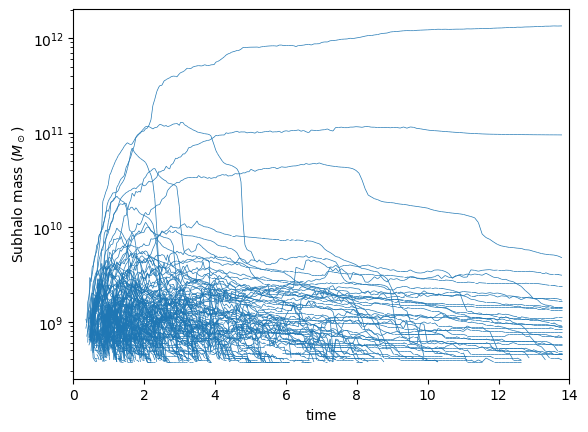

In [20]:
tree1 = mt.plot_mergertree(mt.i_mwall, axis='lookback_time')
plt.xlabel('time')
plt.xlim(0,14)

(0.0, 14.0)

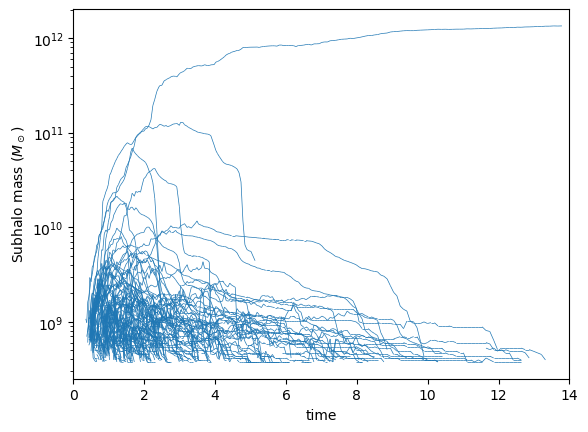

In [21]:
tree1 = mt.plot_mergertree(mt.i_mw, axis='lookback_time')
plt.xlabel('time')
plt.xlim(0,14)

Text(0.5, 0, 'Lookback time [Gyr]')

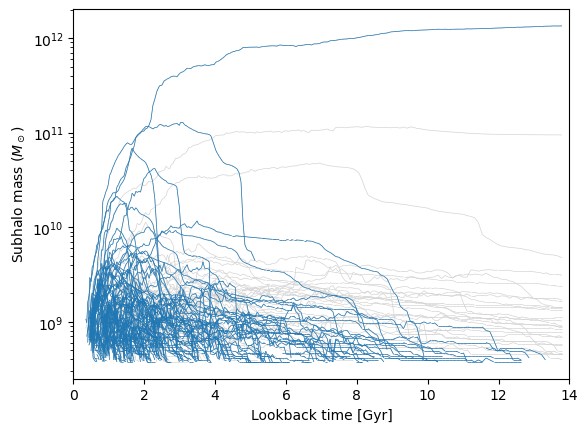

In [22]:
mt.plot_mergertree(mt.i_mwall, axis="lookback_time", color="lightgrey")
mt.plot_mergertree(mt.i_mw, axis="lookback_time")

plt.xlim(0, 14)
plt.xlabel("Lookback time [Gyr]")

I only want to colour the subhalos with mass ratio 0.2 < mu < 0.5  and that have been fully destroyed 2-6Gyr ago.

In [22]:
#here i want to find simulations with at least one MW merger with
#0.2 < μ < 0.5 and the satellite fully destroyed
#2-6 Gyr after the Big Bang

required_sims_mw = []  #simulations that satisfy the MW criteria

required_min = 2  #minimum cosmic time (Gyr after the Big Bang)
required_max = 6  #maximum cosmic time (Gyr after the Big Bang)

for sim_number, fol in enumerate(folnames_new):

    try:  #using try because the kernel keeps shutting down
        with xr.open_dataset(fol / "mergers_mw.nc") as ds:

            #satellite mass
            m_sat = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="subhalo"
            ).load().values

            #main halo mass
            m_main = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="main"
            ).load().values

            mass_ratio = m_sat / m_main  # mass ratio

            #scale factor when the satellite is fully destroyed
            a_destroyed = ds["scale_factor"].sel(
                event="destroyed",
                which="main"
            ).load().values

            #convert scale factor to cosmic time (Gyr after the Big Bang)
            z_destroyed = 1 / a_destroyed - 1
            t_destroyed = Planck18.age(z_destroyed).to_value(u.Gyr)

            #only destroyed satellites
            destroyed = ~ds["survives_to_now"].load().values

            #only consider destroyed mergers with 0.2 < μ < 0.5
            relevant_mergers = (
                destroyed
                & np.isfinite(mass_ratio)
                & (mass_ratio > 0.2)
                & (mass_ratio < 0.5)
            )

            #require destruction at about 2-6 Gyr after the Big Bang
            required = (
                relevant_mergers
                & np.isfinite(t_destroyed)
                & (t_destroyed >= required_min)
                & (t_destroyed <= required_max)
            )

            #number of mergers satisfying the criteria
            n_required = np.sum(required)

            #keep simulation if at least one merger satisfies the criteria
            if n_required >= 1:

                required_sims_mw.append((sim_number, fol, n_required))

    except Exception as e:

        print(f"Simulation {sim_number} failed: {fol}")
        print(e)

print(
    "Simulations with at least one merger with "
    "0.2 < μ < 0.5 and fully destroyed "
    "2-6 Gyr after the Big Bang:",
    len(required_sims_mw)
)

Simulation 27 failed: /net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869
[Errno 2] No such file or directory: '/net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869/mergers_mw.nc'
Simulations with at least one merger with 0.2 < μ < 0.5 and fully destroyed 2-6 Gyr after the Big Bang: 133


In [23]:
print(
    "Simulation numbers with at least one merger with "
    "0.2 < μ < 0.5 and fully destroyed "
    "2-6 Gyr after the Big Bang:"
)

for sim_number, fol, n_required in required_sims_mw:
    print(f"Simulation {sim_number}")

print(f"\nNumber of simulations: {len(required_sims_mw)}")

Simulation numbers with at least one merger with 0.2 < μ < 0.5 and fully destroyed 2-6 Gyr after the Big Bang:
Simulation 0
Simulation 1
Simulation 3
Simulation 4
Simulation 5
Simulation 6
Simulation 7
Simulation 8
Simulation 9
Simulation 10
Simulation 12
Simulation 13
Simulation 14
Simulation 16
Simulation 17
Simulation 21
Simulation 22
Simulation 24
Simulation 25
Simulation 28
Simulation 29
Simulation 30
Simulation 31
Simulation 32
Simulation 35
Simulation 36
Simulation 39
Simulation 40
Simulation 41
Simulation 42
Simulation 43
Simulation 44
Simulation 45
Simulation 46
Simulation 47
Simulation 48
Simulation 49
Simulation 50
Simulation 51
Simulation 52
Simulation 53
Simulation 54
Simulation 55
Simulation 56
Simulation 57
Simulation 58
Simulation 59
Simulation 60
Simulation 66
Simulation 67
Simulation 68
Simulation 69
Simulation 70
Simulation 71
Simulation 72
Simulation 73
Simulation 75
Simulation 76
Simulation 77
Simulation 78
Simulation 79
Simulation 80
Simulation 81
Simulation 82
Si

In [24]:
#now i want to find simulations where the LAST major merger was the GES
#so all the mergers after GES have to be μ < 0.2

last_ges_sims_mw = []

required_min = 2   #Gyr after the Big Bang
required_max = 6   #Gyr after the Big Bang

for sim_number, fol in enumerate(folnames_new):

    try:
        with xr.open_dataset(fol / "mergers_mw.nc") as ds:

            #mass ratio at sat_highestmass
            m_sat = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="subhalo"
            ).load().values

            m_main = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="main"
            ).load().values

            mass_ratio = m_sat / m_main

            #destruction time in cosmic time
            a_destroyed = ds["scale_factor"].sel(
                event="destroyed",
                which="main"
            ).load().values

            z_destroyed = 1 / a_destroyed - 1
            t_destroyed = Planck18.age(z_destroyed).to_value(u.Gyr)

            #only destroyed satellites
            destroyed = ~ds["survives_to_now"].load().values

            #all destroyed mergers with μ > 0.2
            major_mergers = (
                destroyed
                & np.isfinite(mass_ratio)
                & np.isfinite(t_destroyed)
                & (mass_ratio > 0.2)
            )

            n_major = np.sum(major_mergers)

            if n_major == 0:
                continue

            #find the LAST major merger = largest cosmic destruction time
            major_indices = np.where(major_mergers)[0]
            last_major_index = major_indices[np.argmax(t_destroyed[major_indices])]

            last_major_mu = mass_ratio[last_major_index]
            last_major_t = t_destroyed[last_major_index]

            #require that the last major merger is GES-like
            is_ges_like = (
                (last_major_mu > 0.2)
                & (last_major_mu < 0.5)
                & (last_major_t >= required_min)
                & (last_major_t <= required_max)
            )

            if is_ges_like:
                last_ges_sims_mw.append(
                    (sim_number, fol, last_major_index, last_major_mu, last_major_t, n_major)
                )

    except Exception as e:
        print(f"Simulation {sim_number} failed: {fol}")
        print(e)


print("Simulations where the LAST major merger was GES-like:")

for sim_number, fol, idx, mu, t, n_major in last_ges_sims_mw:
    print(f"Simulation {sim_number}")

print(f"\nNumber of simulations: {len(last_ges_sims_mw)}")

Simulation 27 failed: /net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869
[Errno 2] No such file or directory: '/net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869/mergers_mw.nc'
Simulations where the LAST major merger was GES-like:
Simulation 0
Simulation 1
Simulation 4
Simulation 10
Simulation 12
Simulation 14
Simulation 16
Simulation 17
Simulation 22
Simulation 24
Simulation 25
Simulation 28
Simulation 32
Simulation 42
Simulation 43
Simulation 57
Simulation 60
Simulation 66
Simulation 68
Simulation 69
Simulation 72
Simulation 78
Simulation 82
Simulation 90
Simulation 91
Simulation 92
Simulation 93
Simulation 96
Simulation 97
Simulation 100
Simulation 102
Simulation 104
Simulation 117
Simulation 118
Simulation 128
Simulation 131
Simulation 132
Simulation 140
Simulation 141
Simulation 142
Simulation 143
Simulation 150
Simulation 151
Simulation 154
Simulation 155
Simulation 157
Simulation 161
Simulation 163

Number of simulations: 48


In [25]:
#M31 simulations for 169
m31_sims = {
    5, 7, 9, 10, 26, 35, 36, 39, 43, 46, 51, 57, 60, 62, 63, 64,
    70, 72, 73, 75, 77, 82, 85, 86, 87, 88, 93, 97, 110, 113,
    116, 118, 124, 128, 138, 143, 144, 150, 152, 155, 159, 161,
    163, 164
}

#MW simulations where the LAST major merger was GES-like
mw_last_ges_sims = {
    sim_number
    for sim_number, fol, idx, mu, t, n_major in last_ges_sims_mw
}

#overlap between M31 list and MW-last-GES list
overlap = m31_sims & mw_last_ges_sims

print("Simulation numbers satisfying both M31 and MW-last-GES criteria:")

for sim_number in sorted(overlap):
    print(f"Simulation {sim_number}")

print(f"\nNumber of overlapping simulations: {len(overlap)}")

Simulation numbers satisfying both M31 and MW-last-GES criteria:
Simulation 10
Simulation 43
Simulation 57
Simulation 60
Simulation 72
Simulation 82
Simulation 93
Simulation 97
Simulation 118
Simulation 128
Simulation 143
Simulation 150
Simulation 155
Simulation 161
Simulation 163

Number of overlapping simulations: 15


In [26]:
#now i want to find simulations with an LMC-like object

lmc_like_sims_mw = []

required_min = 0.5  #Gyr ago
required_max = 5.0  #Gyr ago

for sim_number, fol in enumerate(folnames_new):

    try:
        with xr.open_dataset(fol / "mergers_mw.nc") as ds:

            survives = ds["survives_to_now"].load().values

            #present-day proxy for surviving satellites
            m_sat_now = ds["SubhaloMass"].sel(
                event="destroyed",
                which="subhalo"
            ).load().values

            #exclude the MW itself
            subhalo_now = ds["Subhalo"].sel(
                event="destroyed",
                which="subhalo"
            ).load().values

            main_now = ds["Subhalo"].sel(
                event="destroyed",
                which="main"
            ).load().values

            is_not_main = subhalo_now != main_now

            #mass ratio at r200_first, kept for information only
            m_sat_r200 = ds["SubhaloMass"].sel(
                event="r200_first",
                which="subhalo"
            ).load().values

            m_main_r200 = ds["SubhaloMass"].sel(
                event="r200_first",
                which="main"
            ).load().values

            mu_r200 = m_sat_r200 / m_main_r200

            #peak satellite mass
            m_sat_peak = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="subhalo"
            ).load().values

            m_main_peak = ds["SubhaloMass"].sel(
                event="sat_highestmass",
                which="main"
            ).load().values

            mu_peak = m_sat_peak / m_main_peak

            #present-day proxy for MW main mass
            m_main_now = ds["SubhaloMass"].sel(
                event="destroyed",
                which="main"
            ).load().values

            peak_fraction = m_sat_peak / m_main_now

            #r200_first time in lookback time
            a_r200 = ds["scale_factor"].sel(
                event="r200_first",
                which="main"
            ).load().values

            z_r200 = 1 / a_r200 - 1
            t_r200 = Planck18.lookback_time(z_r200).to_value(u.Gyr)

            #surviving satellites only, excluding the main halo
            surviving_satellites = (
                survives
                & is_not_main
                & np.isfinite(m_sat_peak)
            )

            if np.sum(surviving_satellites) == 0:
                continue

            #criterion 1: most massive surviving satellite by peak mass
            surviving_indices = np.where(surviving_satellites)[0]
            lmc_index = surviving_indices[
                np.argmax(m_sat_peak[surviving_indices])
            ]

            #criteria 2, 3 and 4
            is_lmc_like = (
                np.isfinite(t_r200[lmc_index])
                & np.isfinite(mu_peak[lmc_index])
                & np.isfinite(peak_fraction[lmc_index])
                & (t_r200[lmc_index] > required_min)
                # removed: & (t_r200[lmc_index] < required_max)
                & (mu_peak[lmc_index] > 0.1)
                & (mu_peak[lmc_index] < 0.2)
                & (peak_fraction[lmc_index] > 0.05)
                & (peak_fraction[lmc_index] < 0.20)
            )

            if is_lmc_like:
                lmc_like_sims_mw.append(
                    (
                        sim_number,
                        fol,
                        lmc_index,
                        mu_peak[lmc_index],
                        mu_r200[lmc_index],
                        t_r200[lmc_index],
                        peak_fraction[lmc_index],
                        m_sat_peak[lmc_index],
                        m_sat_now[lmc_index]
                    )
                )

    except Exception as e:
        print(f"Simulation {sim_number} failed: {fol}")
        print(e)


print("Simulations with an LMC-like object:")

for sim_number, fol, idx, mu_peak_val, mu_r200_val, t, peak_frac, m_peak, m_now in lmc_like_sims_mw:
    print(
        f"Simulation {sim_number}: "
        f"LMC index = {idx}, "
        f"mu_peak = {mu_peak_val:.3f}, "
        f"mu_r200 = {mu_r200_val:.3f}, "
        f"t_r200 = {t:.2f} Gyr ago, "
        f"M_peak/M_main_now = {peak_frac:.3f}, "
        f"M_sat_peak = {m_peak:.3e}, "
        f"M_sat_now = {m_now:.3e}"
    )

print(f"\nNumber of simulations: {len(lmc_like_sims_mw)}")

Simulation 27 failed: /net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869
[Errno 2] No such file or directory: '/net/gaia2/data/users/wempe/rerun_169/runz98.11_mcmc_869/mergers_mw.nc'
Simulations with an LMC-like object:
Simulation 6: LMC index = 259, mu_peak = 0.149, mu_r200 = 0.087, t_r200 = 4.75 Gyr ago, M_peak/M_main_now = 0.089, M_sat_peak = 7.833e+00, M_sat_now = 2.455e+00
Simulation 8: LMC index = 236, mu_peak = 0.118, mu_r200 = 0.086, t_r200 = 5.64 Gyr ago, M_peak/M_main_now = 0.077, M_sat_peak = 8.956e+00, M_sat_now = 4.367e-01
Simulation 14: LMC index = 232, mu_peak = 0.165, mu_r200 = 0.084, t_r200 = 6.06 Gyr ago, M_peak/M_main_now = 0.072, M_sat_peak = 7.056e+00, M_sat_now = 2.075e-01
Simulation 37: LMC index = 185, mu_peak = 0.108, mu_r200 = 0.093, t_r200 = 3.40 Gyr ago, M_peak/M_main_now = 0.083, M_sat_peak = 6.179e+00, M_sat_now = 2.847e+00
Simulation 45: LMC index = 198, mu_peak = 0.160, mu_r200 = 0.036, t_r200 = 1.60 Gyr ago, M_peak/M_main_now = 0.063, M_sat_peak =

In [27]:
#GES and LMC overlap Milky Way
import matplotlib.pyplot as plt

#extract simulation numbers
ges_sims = set([item[0] for item in last_ges_sims_mw])
lmc_sims = set([item[0] for item in lmc_like_sims_mw])

#overlap
overlap_sims = ges_sims & lmc_sims

print("GES-like simulations:", sorted(ges_sims))
print("LMC-like simulations:", sorted(lmc_sims))
print("Overlap simulations:", sorted(overlap_sims))
print("Number of overlapping simulations:", len(overlap_sims))

GES-like simulations: [0, 1, 4, 10, 12, 14, 16, 17, 22, 24, 25, 28, 32, 42, 43, 57, 60, 66, 68, 69, 72, 78, 82, 90, 91, 92, 93, 96, 97, 100, 102, 104, 117, 118, 128, 131, 132, 140, 141, 142, 143, 150, 151, 154, 155, 157, 161, 163]
LMC-like simulations: [6, 8, 14, 37, 45, 46, 50, 86, 97, 104, 127, 128, 139, 143, 149, 153, 163]
Overlap simulations: [14, 97, 104, 128, 143, 163]
Number of overlapping simulations: 6


In [28]:
#MW simulations with an LMC-like object
mw_lmc_sims = {
    sim_number
    for sim_number, fol, idx, mu_peak, mu_r200, t, peak_frac, m_peak, m_now
    in lmc_like_sims_mw
}

#overlap between M31 list and MW-LMC list
overlap_lmc = m31_sims & mw_lmc_sims

print("Simulation numbers satisfying both M31 and MW-LMC criteria:")

for sim_number in sorted(overlap_lmc):
    print(f"Simulation {sim_number}")

print(f"\nNumber of overlapping simulations: {len(overlap_lmc)}")

Simulation numbers satisfying both M31 and MW-LMC criteria:
Simulation 46
Simulation 86
Simulation 97
Simulation 128
Simulation 143
Simulation 163

Number of overlapping simulations: 6


In [29]:
#overlap M31 simulations, with MW GES like merger and an LMC like object
overlap_all = m31_sims & mw_last_ges_sims & mw_lmc_sims

print("Simulation numbers satisfying M31, MW-last-GES, and MW-LMC criteria:")

for sim_number in sorted(overlap_all):
    print(f"Simulation {sim_number}")

print(f"\nNumber of overlapping simulations: {len(overlap_all)}")

Simulation numbers satisfying M31, MW-last-GES, and MW-LMC criteria:
Simulation 97
Simulation 128
Simulation 143
Simulation 163

Number of overlapping simulations: 4


In [30]:
#i run these cells as an extra check to make sure that the ratio of the LMC like object is < than the ratio of the GES like merger

In [31]:
overlap_ges_lmc = mw_last_ges_sims & mw_lmc_sims

for sim_number in sorted(overlap_ges_lmc):

    ges_entry = [
        x for x in last_ges_sims_mw
        if x[0] == sim_number
    ][0]

    lmc_entry = [
        x for x in lmc_like_sims_mw
        if x[0] == sim_number
    ][0]

    _, _, ges_idx, ges_mu, ges_t, n_major = ges_entry
    _, _, lmc_idx, lmc_mu, lmc_t, lmc_peak_frac, lmc_m_now = lmc_entry

    print(
        f"Simulation {sim_number}: "
        f"GES index = {ges_idx}, "
        f"LMC index = {lmc_idx}"
    )

ValueError: too many values to unpack (expected 7)

In [ ]:
print(
    f"GES mu = {ges_mu:.3f}, "
    f"LMC mu = {lmc_mu:.3f}"
)

In [ ]:
with xr.open_dataset(folnames_new[sim_number] / "mergers_mw.nc") as ds:

    m_sat_peak = ds["SubhaloMass"].sel(
        event="sat_highestmass",
        which="subhalo"
    ).load().values

    print(
        f"GES peak mass = {m_sat_peak[ges_idx]:.3e}, "
        f"LMC peak mass = {m_sat_peak[lmc_idx]:.3e}"
    )

In [ ]:
with xr.open_dataset(folnames_new[sim_number] / "mergers_mw.nc") as ds:

    m_sat_peak = ds["SubhaloMass"].sel(
        event="sat_highestmass",
        which="subhalo"
    ).load().values

    m_main_peak = ds["SubhaloMass"].sel(
        event="sat_highestmass",
        which="main"
    ).load().values

    print(f"GES satellite peak mass = {m_sat_peak[ges_idx]:.3e}")
    print(f"GES main peak mass      = {m_main_peak[ges_idx]:.3e}")
    print(f"GES mu peak             = {m_sat_peak[ges_idx] / m_main_peak[ges_idx]:.3f}")

    print(f"LMC satellite peak mass = {m_sat_peak[lmc_idx]:.3e}")
    print(f"LMC main peak mass      = {m_main_peak[lmc_idx]:.3e}")
    print(f"LMC mu peak             = {m_sat_peak[lmc_idx] / m_main_peak[lmc_idx]:.3f}")